# Fetal Health Classification — CTG Dataset


## 3.1  Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, joblib
warnings.filterwarnings('ignore')

# scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier



All libraries imported successfully.


In [3]:
# ── Load Data ────────────────────────────────────────────────────────────────
df_raw = pd.read_excel('D:\ML project\Machine-Learning-Project\CTG.xls', sheet_name='Raw Data', header=0)
df_raw = df_raw.dropna(subset=['NSP']).reset_index(drop=True)

FEATURES = ['LB','AC','FM','UC','ASTV','MSTV','ALTV','MLTV',
            'Width','Min','Max','Nmax','Nzeros','Mode',
            'Mean','Median','Variance','Tendency']
TARGET = 'NSP'

df = df_raw[FEATURES + [TARGET]].copy()
df[TARGET] = df[TARGET].astype(int)   # 1=Normal, 2=Suspect, 3=Pathologic

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2126, 19)


,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2
1,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1
2,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1
3,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1
4,132.0,4.0,0.0,5.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1


## 3.2  EDA, Preprocessing & Train-Test Split

In [4]:
print("=== Dataset Info ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Summary Statistics ===")
df.describe()

=== Dataset Info ===
LB          float64
AC          float64
FM          float64
UC          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Min         float64
Max         float64
Nmax        float64
Nzeros      float64
Mode        float64
Mean        float64
Median      float64
Variance    float64
Tendency    float64
NSP           int64
dtype: object

=== Missing Values ===
LB          0
AC          0
FM          0
UC          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
NSP         0
dtype: int64

=== Summary Statistics ===


,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,2.722484,7.241298,3.659925,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,3.560850,37.125309,2.847094,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,1.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,1.000000,0.000000,3.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,4.000000,2.000000,5.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,26.000000,564.000000,23.000000,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


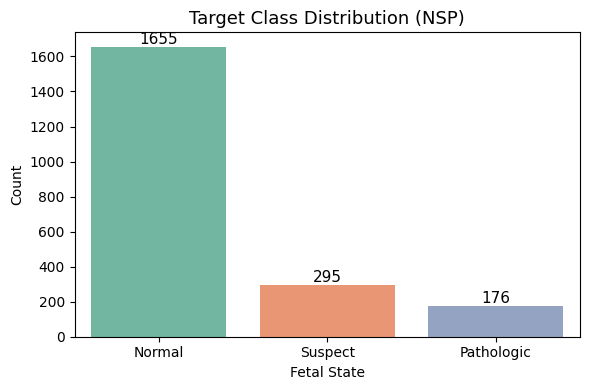

NSP
1    1655
2     295
3     176
Name: count, dtype: int64


In [5]:

label_map = {1: 'Normal', 2: 'Suspect', 3: 'Pathologic'}
counts = df[TARGET].value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=counts.index.map(label_map), y=counts.values, palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Target Class Distribution (NSP)', fontsize=13)
plt.xlabel('Fetal State'); plt.ylabel('Count')
plt.tight_layout(); plt.savefig('class_distribution.png', dpi=100); plt.show()
print(counts)

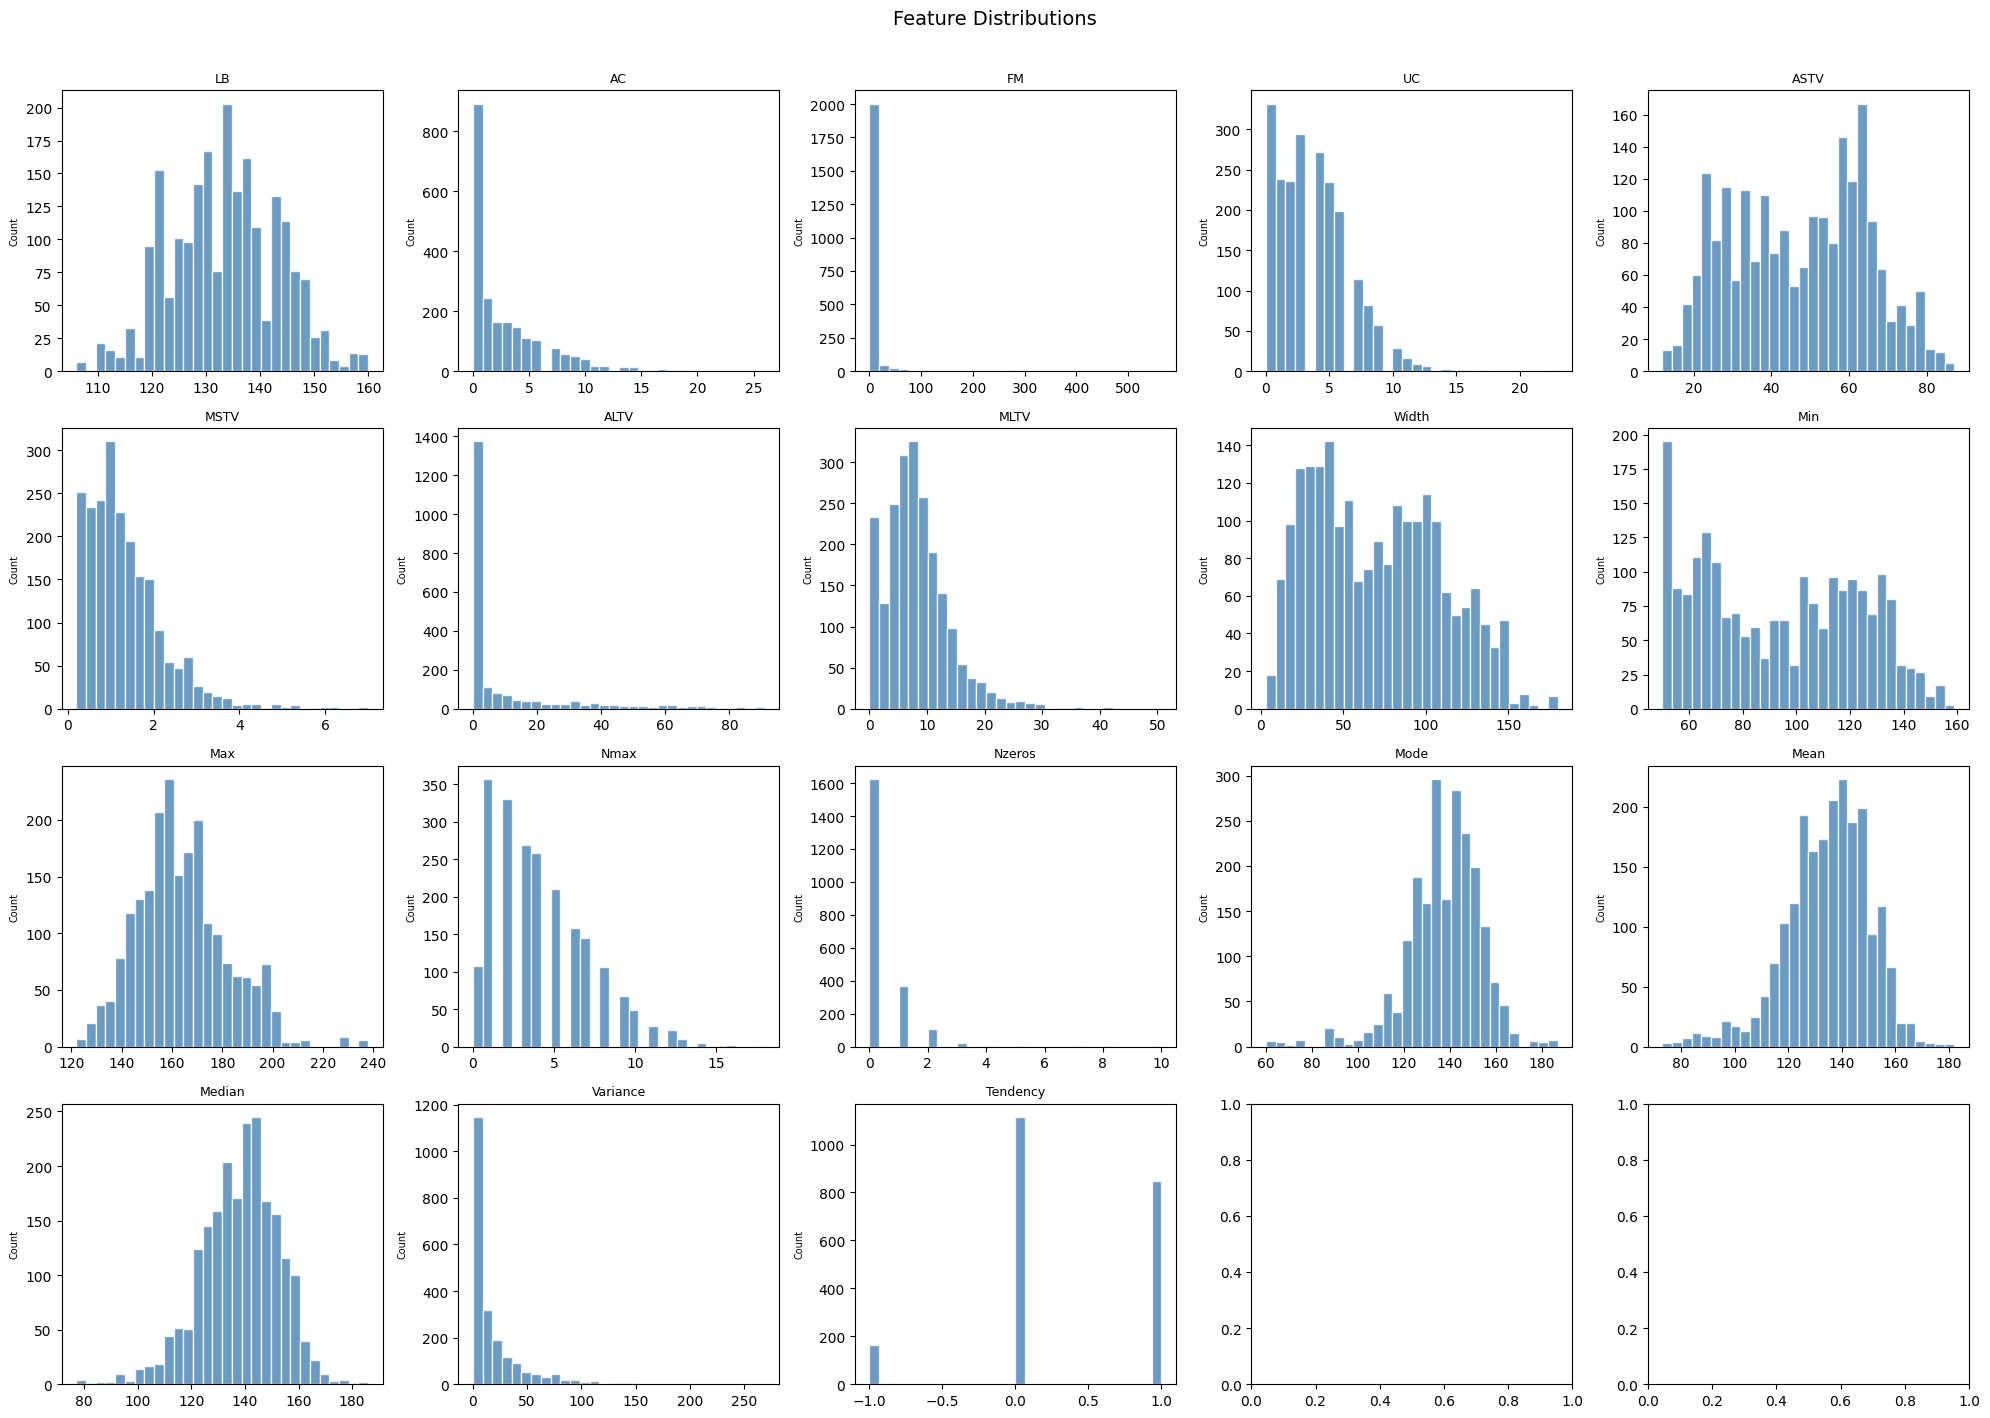

In [6]:
# ── Feature distributions ─────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
for ax, col in zip(axes.flatten(), FEATURES):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(''); ax.set_ylabel('Count', fontsize=7)
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100)
plt.show()

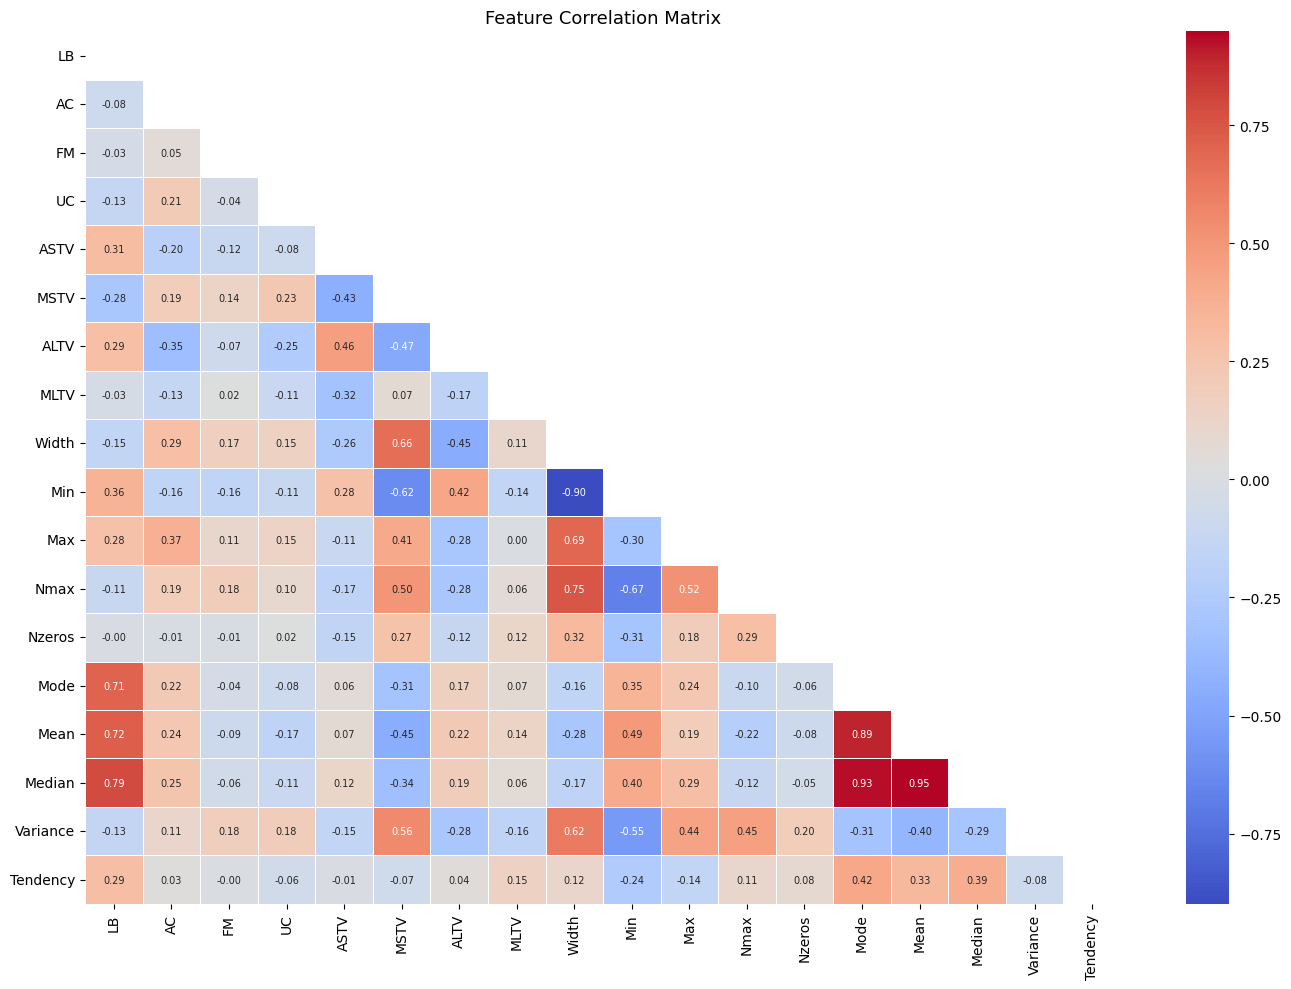

In [7]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 10))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()

In [8]:
# ── Outlier Detection (IQR method) ─────────
def remove_outliers_iqr(data, cols, factor=3.0):
    mask = pd.Series([True]*len(data), index=data.index)
    for col in cols:
        Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= (data[col] >= Q1 - factor*IQR) & (data[col] <= Q3 + factor*IQR)
    return data[mask].reset_index(drop=True)

df_clean = remove_outliers_iqr(df, FEATURES, factor=3.0)
print(f"Before outlier removal: {len(df)} rows")
print(f"After  outlier removal: {len(df_clean)} rows  ({len(df)-len(df_clean)} removed)")

Before outlier removal: 2126 rows
After  outlier removal: 1261 rows  (865 removed)


In [9]:
# ── Multicollinearity check: drop high-corr pairs (|r|>0.95) 
corr_matrix = df_clean[FEATURES].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Highly correlated features to drop:", to_drop)

FEATURES_FINAL = [f for f in FEATURES if f not in to_drop]
print("Final feature set:", FEATURES_FINAL)

Highly correlated features to drop: ['Median']
Final feature set: ['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Variance', 'Tendency']


In [10]:
# ── Train-Test Split (80/20, stratified) ─────────────────────────────────────
X = df_clean[FEATURES_FINAL].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set:  {X_train_sc.shape}")
print(f"Test set:      {X_test_sc.shape}")
print(f"Class split in train: {dict(zip(*np.unique(y_train, return_counts=True)))}")

# Save scaler for Streamlit app
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(FEATURES_FINAL, 'features.pkl')
print("Scaler and feature list saved.")

Training set:  (1008, 17)
Test set:      (253, 17)
Class split in train: {np.int64(1): np.int64(844), np.int64(2): np.int64(122), np.int64(3): np.int64(42)}
Scaler and feature list saved.


## 3.3  Model Training — Base Models

In [11]:
# ── Define base models ────────────────────────────────────────────────────────
base_models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(random_state=42),
    'KNN':                  KNeighborsClassifier()
}

base_results = {}
for name, model in base_models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    base_results[name] = acc
    print(f"{name:25s}  Accuracy: {acc:.4f}")

Logistic Regression        Accuracy: 0.9170
Decision Tree              Accuracy: 0.9368
Random Forest              Accuracy: 0.9328
KNN                        Accuracy: 0.9091


## 3.4  Model Evaluation

In [12]:
# ── Classification reports for all base models ────────────────────────────────
all_reports = {}
for name, model in base_models.items():
    y_pred = model.predict(X_test_sc)
    report = classification_report(y_test, y_pred,
                                   target_names=['Normal','Suspect','Pathologic'],
                                   output_dict=True)
    all_reports[name] = report
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, y_pred,
                                target_names=['Normal','Suspect','Pathologic']))

with open('classification_report.json', 'w') as f:
    json.dump(all_reports, f, indent=2)
print("\nclassification_report.json saved.")


  Logistic Regression
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       212
     Suspect       0.69      0.60      0.64        30
  Pathologic       1.00      0.82      0.90        11

    accuracy                           0.92       253
   macro avg       0.88      0.80      0.83       253
weighted avg       0.91      0.92      0.91       253


  Decision Tree
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.96       212
     Suspect       0.79      0.87      0.83        30
  Pathologic       0.78      0.64      0.70        11

    accuracy                           0.94       253
   macro avg       0.84      0.82      0.83       253
weighted avg       0.94      0.94      0.94       253


  Random Forest
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       212
     Suspect       0.78      0.83      0.81        30
  Pathologic      

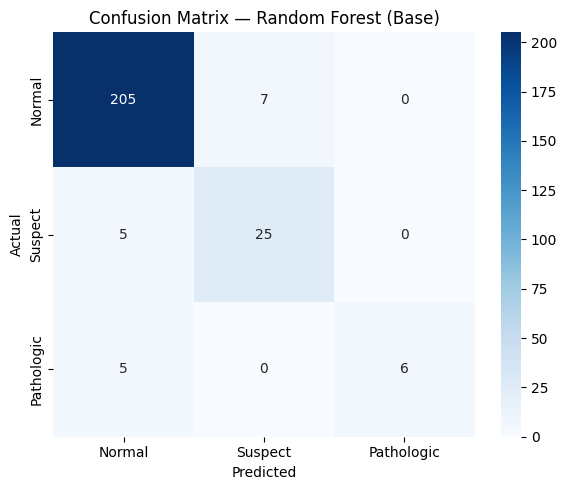

In [13]:
# ── Confusion Matrix — Random Forest (best expected) ─────────────────────────
rf_pred = base_models['Random Forest'].predict(X_test_sc)
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Suspect','Pathologic'],
            yticklabels=['Normal','Suspect','Pathologic'])
plt.title('Confusion Matrix — Random Forest (Base)', fontsize=12)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_rf_base.png', dpi=100)
plt.show()

In [14]:
# ── Stratified K-Fold Cross-Validation (5-fold) ───────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== 5-Fold Stratified Cross-Validation (Accuracy) ===\n")
cv_results = {}
for name, model in base_models.items():
    scores = cross_val_score(model, X_train_sc, y_train,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}  Scores: {np.round(scores,4)}")

=== 5-Fold Stratified Cross-Validation (Accuracy) ===

Logistic Regression        Mean: 0.9057  Std: 0.0212  Scores: [0.9356 0.8911 0.9257 0.8806 0.8955]
Decision Tree              Mean: 0.9295  Std: 0.0190  Scores: [0.9109 0.9505 0.9505 0.9055 0.9303]
Random Forest              Mean: 0.9464  Std: 0.0162  Scores: [0.9455 0.9455 0.9752 0.9254 0.9403]
KNN                        Mean: 0.9018  Std: 0.0193  Scores: [0.901  0.901  0.9356 0.8756 0.8955]


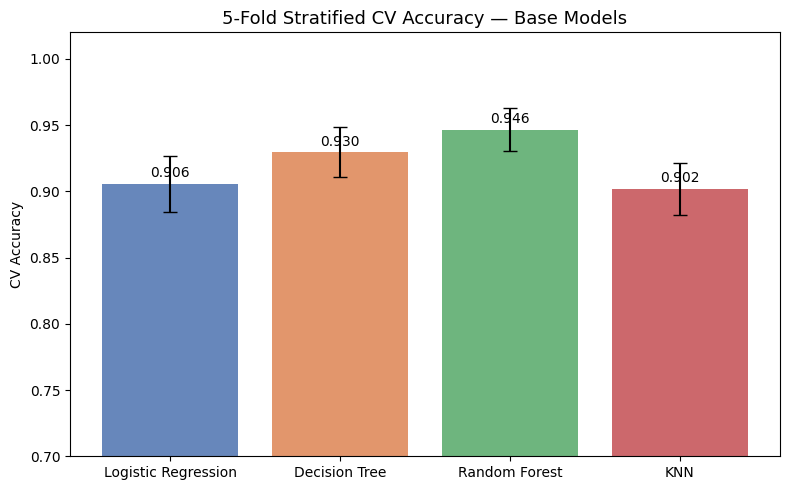

In [15]:
# ── CV Results Bar Chart ──────────────────────────────────────────────────────
means = [cv_results[m].mean() for m in base_models]
stds  = [cv_results[m].std()  for m in base_models]

plt.figure(figsize=(8, 5))
bars = plt.bar(base_models.keys(), means, yerr=stds, capsize=5,
               color=['#4C72B0','#DD8452','#55A868','#C44E52'], alpha=0.85)
plt.ylim(0.7, 1.02)
plt.ylabel('CV Accuracy')
plt.title('5-Fold Stratified CV Accuracy — Base Models', fontsize=13)
for bar, mean in zip(bars, means):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{mean:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('cv_accuracy_base.png', dpi=100)
plt.show()

## 3.5  Testing on New Instances (Base Models)

In [16]:
# ── Test with a sample from the test set ─────────────────────────────────────
sample_idx = 5
sample_raw  = X_test[sample_idx].reshape(1, -1)
sample_sc   = scaler.transform(sample_raw)
true_label  = y_test[sample_idx]

label_map = {1: 'Normal', 2: 'Suspect', 3: 'Pathologic'}
print(f"True label: {label_map[true_label]}\n")
for name, model in base_models.items():
    pred = model.predict(sample_sc)[0]
    print(f"{name:25s}  Predicted: {label_map[pred]}")

True label: Normal

Logistic Regression        Predicted: Normal
Decision Tree              Predicted: Normal
Random Forest              Predicted: Normal
KNN                        Predicted: Normal


## 3.6  Model Optimization — Hyperparameter Tuning

In [17]:
# ── Tune Logistic Regression ──────────────────────────────────────────────────
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'penalty': ['l2']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=2000, random_state=42),
                       lr_params, cv=skf, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_sc, y_train)
print("Best LR params:", lr_grid.best_params_)
print(f"Best LR CV Acc: {lr_grid.best_score_:.4f}")

Best LR params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR CV Acc: 0.9147


In [18]:
# ── Tune Decision Tree ────────────────────────────────────────────────────────
dt_params = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=skf, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_sc, y_train)
print("Best DT params:", dt_grid.best_params_)
print(f"Best DT CV Acc: {dt_grid.best_score_:.4f}")

Best DT params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 10}
Best DT CV Acc: 0.9375


In [20]:
# ── Tune Random Forest (RandomizedSearchCV for speed) ────────────────────────
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
rf_rand = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                             rf_params, n_iter=20, cv=skf,
                             scoring='accuracy', n_jobs=-1, random_state=42)
rf_rand.fit(X_train_sc, y_train)
print("Best RF params:", rf_rand.best_params_)
print(f"Best RF CV Acc: {rf_rand.best_score_:.4f}")

Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 10}
Best RF CV Acc: 0.9464


In [21]:
# ── Tune KNN ──────────────────────────────────────────────────────────────────
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(),
                        knn_params, cv=skf, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_sc, y_train)
print("Best KNN params:", knn_grid.best_params_)
print(f"Best KNN CV Acc: {knn_grid.best_score_:.4f}")

Best KNN params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV Acc: 0.9067


In [22]:
# ── Compare tuned models on test set ─────────────────────────────────────────
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Decision Tree':       dt_grid.best_estimator_,
    'Random Forest':       rf_rand.best_estimator_,
    'KNN':                 knn_grid.best_estimator_
}

print("\n=== Tuned Model Test Accuracy ===\n")
tuned_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    tuned_results[name] = acc
    print(f"{name:25s}  Accuracy: {acc:.4f}")

best_name = max(tuned_results, key=tuned_results.get)
print(f"\n Best model: {best_name}  ({tuned_results[best_name]:.4f})")


=== Tuned Model Test Accuracy ===

Logistic Regression        Accuracy: 0.9170
Decision Tree              Accuracy: 0.9407
Random Forest              Accuracy: 0.9289
KNN                        Accuracy: 0.9170

✅ Best model: Decision Tree  (0.9407)


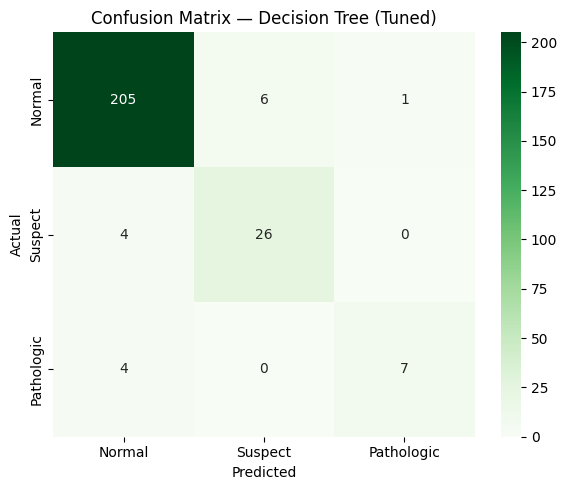

              precision    recall  f1-score   support

      Normal       0.96      0.97      0.96       212
     Suspect       0.81      0.87      0.84        30
  Pathologic       0.88      0.64      0.74        11

    accuracy                           0.94       253
   macro avg       0.88      0.82      0.85       253
weighted avg       0.94      0.94      0.94       253



In [23]:
# ── Confusion Matrix for best tuned model ────────────────────────────────────
best_model = tuned_models[best_name]
y_pred_best = best_model.predict(X_test_sc)
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Suspect','Pathologic'],
            yticklabels=['Normal','Suspect','Pathologic'])
plt.title(f'Confusion Matrix — {best_name} (Tuned)', fontsize=12)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_best_tuned.png', dpi=100)
plt.show()

print(classification_report(y_test, y_pred_best,
                            target_names=['Normal','Suspect','Pathologic']))

In [25]:
# ── Feature Importance (if RF is best) ───────────────────────────────────────
if 'Random Forest' in best_name:
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': FEATURES_FINAL, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
    plt.title('Feature Importances — Random Forest (Tuned)', fontsize=12)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100)
    plt.show()

## Testing Tuned Model on New Instances

In [26]:
# ── Predict on 3 new samples from the test set ───────────────────────────────
label_map = {1: 'Normal', 2: 'Suspect', 3: 'Pathologic'}
for idx in [0, 10, 25]:
    raw   = X_test[idx].reshape(1, -1)
    sc    = scaler.transform(raw)
    pred  = best_model.predict(sc)[0]
    true  = y_test[idx]
    match = "✅" if pred == true else "❌"
    print(f"Sample {idx:3d}  |  True: {label_map[true]:12s}  |  Predicted: {label_map[pred]:12s}  {match}")

Sample   0  |  True: Normal        |  Predicted: Normal        ✅
Sample  10  |  True: Normal        |  Predicted: Normal        ✅
Sample  25  |  True: Suspect       |  Predicted: Suspect       ✅


## 3.7  Model Serialization

In [27]:
# ── Save best tuned model as rf_best_model.pkl ────────────────────────────────
model_filename = 'rf_best_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model saved to '{model_filename}'")

# ── Verify: reload and predict ────────────────────────────────────────────────
loaded_model = joblib.load(model_filename)
sample = X_test[0].reshape(1, -1)
sample_sc = scaler.transform(sample)
pred = loaded_model.predict(sample_sc)[0]
print(f"Loaded model prediction on sample[0]: {label_map[pred]}  (True: {label_map[y_test[0]]})")

Best model saved to 'rf_best_model.pkl'
Loaded model prediction on sample[0]: Normal  (True: Normal)


In [29]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  PROJECT SUMMARY")
print("="*55)
print(f"  Dataset:         CTG (Cardiotocography), {len(df_clean)} samples")
print(f"  Features used:   {FEATURES_FINAL}")
print(f"  Task:            3-class classification (NSP)")
print(f"  Best model:      {best_name}")
print(f"  Test Accuracy:   {tuned_results[best_name]:.4f}")
print("="*55)
print("\nFiles saved:")
for f in ['scaler.pkl','features.pkl','rf_best_model.pkl',
          'classification_report.json','class_distribution.png',
          'confusion_matrix_best_tuned.png']:
    print(f"  {f}")


  PROJECT SUMMARY
  Dataset:         CTG (Cardiotocography), 1261 samples
  Features used:   ['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Variance', 'Tendency']
  Task:            3-class classification (NSP)
  Best model:      Decision Tree
  Test Accuracy:   0.9407

Files saved:
  scaler.pkl
  features.pkl
  rf_best_model.pkl
  classification_report.json
  class_distribution.png
  confusion_matrix_best_tuned.png
